<a href="https://colab.research.google.com/github/varun0852/ML-PROJECTS/blob/main/Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files
uploaded = files.upload("C:/Users/HP/Downloads/Advertising_Data.csv")


Saving Advertising_Data.csv to C:/Users/HP/Downloads/Advertising_Data.csv/Advertising_Data.csv


In [ ]:
df = pd.read_csv("C:/Users/HP/Downloads/Advertising_Data.csv/Advertising_Data.csv")

In [ ]:
df.head()

,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing,Product_Sold
0,281.42,538.80,123.94,349.30,242.77,910.10,7164.0
1,702.97,296.53,558.13,180.55,781.06,132.43,5055.0
2,313.14,295.94,642.96,505.71,438.91,464.23,6154.0
3,898.52,61.27,548.73,240.93,278.96,432.27,5480.0
4,766.52,550.72,651.91,666.33,396.33,841.93,9669.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TV                    300 non-null    float64
 1   Billboards            300 non-null    float64
 2   Google_Ads            300 non-null    float64
 3   Social_Media          300 non-null    float64
 4   Influencer_Marketing  300 non-null    float64
 5   Affiliate_Marketing   300 non-null    float64
 6   Product_Sold          300 non-null    float64
dtypes: float64(7)
memory usage: 16.5 KB


In [ ]:
df.describe()

,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing,Product_Sold
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,517.431000,502.644933,512.444133,489.800100,465.732567,484.430633,7031.523333
std,288.114792,275.842369,285.422376,273.883915,288.314080,277.955458,1703.614951
min,1.040000,3.630000,14.860000,11.690000,0.770000,6.740000,2259.000000
25%,273.090000,277.912500,250.530000,265.612500,214.480000,267.677500,5922.500000
50%,513.970000,533.020000,528.965000,486.385000,480.355000,451.315000,7051.000000
75%,774.275000,745.005000,763.345000,695.117500,703.092500,721.065000,8278.000000
max,998.100000,995.320000,999.230000,996.160000,999.830000,987.580000,12227.000000


In [ ]:
features = df[["TV" , "Billboards" , "Google_Ads" , "Social_Media" , "Influencer_Marketing" , "Affiliate_Marketing"]]

In [ ]:
print(features)

         TV  Billboards  Google_Ads  Social_Media  Influencer_Marketing  \
0    281.42      538.80      123.94        349.30                242.77   
1    702.97      296.53      558.13        180.55                781.06   
2    313.14      295.94      642.96        505.71                438.91   
3    898.52       61.27      548.73        240.93                278.96   
4    766.52      550.72      651.91        666.33                396.33   
..      ...         ...         ...           ...                   ...   
295  770.05      501.36      694.60        172.26                572.26   
296  512.38      250.83      373.78        366.95                987.14   
297  998.10      858.75      781.06         60.61                174.63   
298  322.35      681.22      640.29        343.65                534.22   
299  476.45      884.77      301.79        802.30                434.82   

     Affiliate_Marketing  
0                 910.10  
1                 132.43  
2                 

<Axes: >

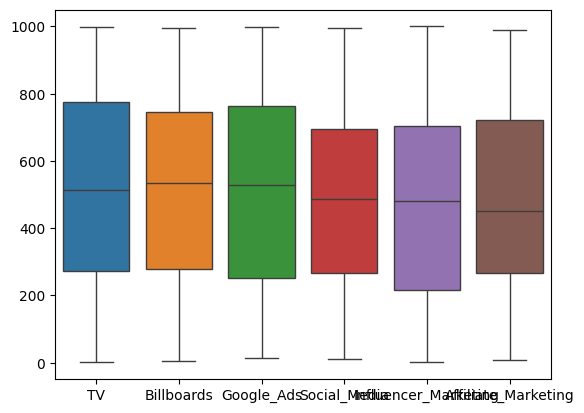

In [ ]:
sns.boxplot(features)

In [ ]:
Q1 = features["TV"].quantile(0.25)
Q3 = features["TV"].quantile(0.75)
iqr = Q3-Q1
lower_fence = Q1-1.5*iqr
upper_fence = Q3+1.5*iqr
trimmed_features = features[(features["TV"] >= lower_fence) & (features["TV"]<= upper_fence)]

In [ ]:
trimmed_features

,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing
0,281.42,538.80,123.94,349.30,242.77,910.10
1,702.97,296.53,558.13,180.55,781.06,132.43
2,313.14,295.94,642.96,505.71,438.91,464.23
3,898.52,61.27,548.73,240.93,278.96,432.27
4,766.52,550.72,651.91,666.33,396.33,841.93
...,...,...,...,...,...,...
295,770.05,501.36,694.60,172.26,572.26,410.56
296,512.38,250.83,373.78,366.95,987.14,509.03
297,998.10,858.75,781.06,60.61,174.63,213.53
298,322.35,681.22,640.29,343.65,534.22,648.71


In [ ]:
negative_counts = 0 # use to check corrupted value
for i in features["TV"]:
  if i < 0:
    negative_counts += 1
print(negative_counts)


0


In [ ]:
duplicates = df[df.duplicated()]# use to check duplicates
print(duplicates)

Empty DataFrame
Columns: [TV, Billboards, Google_Ads, Social_Media, Influencer_Marketing, Affiliate_Marketing, Product_Sold]
Index: []


In [ ]:
trimmed_features.corr() # use to check correlation between column

,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing
TV,1.000000,-0.028851,0.025265,-0.038993,0.009970,0.087524
Billboards,-0.028851,1.000000,0.052991,0.048722,-0.005815,-0.041060
Google_Ads,0.025265,0.052991,1.000000,0.040265,-0.059243,-0.131834
Social_Media,-0.038993,0.048722,0.040265,1.000000,-0.042679,-0.019522
Influencer_Marketing,0.009970,-0.005815,-0.059243,-0.042679,1.000000,-0.047093
Affiliate_Marketing,0.087524,-0.041060,-0.131834,-0.019522,-0.047093,1.000000


<Axes: >

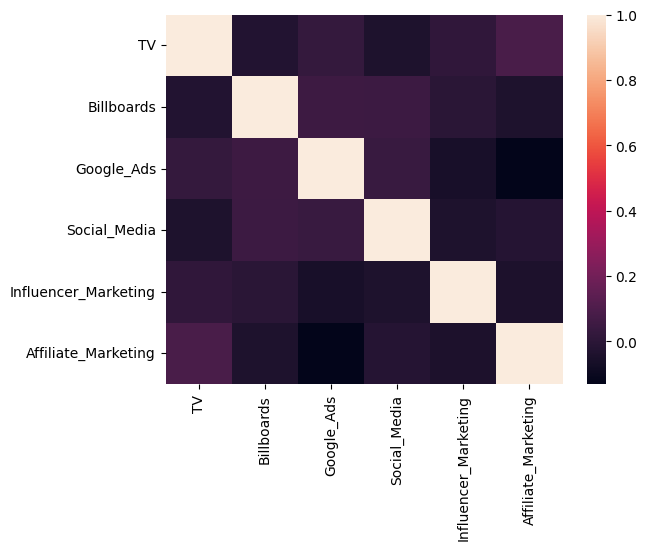

In [ ]:
sns.heatmap(trimmed_features.corr())

<Axes: xlabel='TV', ylabel='Product_Sold'>

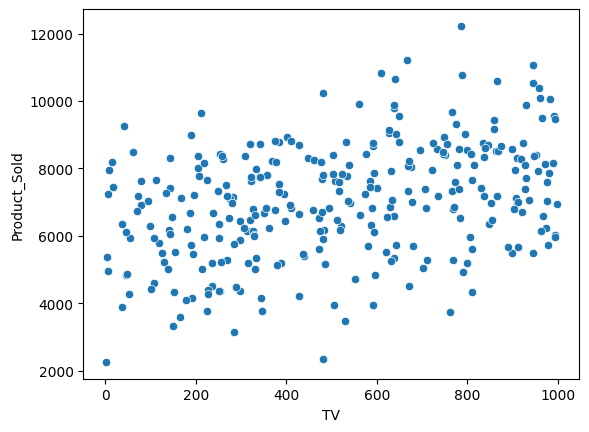

In [ ]:
sns.scatterplot(data = df , x = "TV" , y = "Product_Sold")

In [ ]:
label = df["Product_Sold"]

In [ ]:
xtrain , xtest , ytrain , ytest = train_test_split (features , label , test_size = 0.2 , random_state = 42)
# we are training our model with this command
# train is use to train the model
# test is use for evaluation of the data
# label help machine to learn
# test size = it divide the data in ratio
# random state = random state freeze sample data

In [ ]:
algorithm = LinearRegression()

In [ ]:
algorithm.fit(xtrain , ytrain) # we are training our model with this command

LinearRegression()

In [ ]:
algorithm.coef_

array([2.00182317, 2.9985323 , 1.49807126, 2.49979705, 1.19965944,
       3.99662486])

In [ ]:
algorithm.predict([[313.14 ,295.94 , 642.96 , 505.71 , 438.91 , 464.23 ]]) # we are predicting the values

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6124.85198182])

In [ ]:
ypred = algorithm.predict(xtest)
ypred

array([ 5734.51474852,  8576.95043805,  8269.78883014,  8650.615784  ,
        8297.30250967,  4351.47197046, 10828.12307045,  8364.09532846,
        7621.28440629,  4205.43666241,  5900.80099742,  5955.50103911,
        4349.88712412,  8942.83593365,  6353.08491399,  7840.76396044,
        7657.45385032,  7452.72723607,  8684.9429274 ,  9505.50501202,
        4164.433298  ,  7798.97951505,  6793.76696375,  9549.0265995 ,
        7388.68848998,  8790.16635144,  2361.69474495,  6844.742317  ,
        6426.46400923,  8401.27144831,  7925.92164893,  6832.98248873,
        7392.90250561,  8995.93133387,  9122.01084037,  6824.28435262,
        3735.61012148,  5498.75342291,  6367.85412348,  5687.85766169,
        9555.00966335,  7843.3524084 ,  6816.14820736, 10544.49194658,
        6872.03381161,  7709.31335114,  8683.42682909,  5242.35667315,
        8331.44941582,  5924.42773629,  7265.96871294,  5299.19403172,
        8216.34660908,  8754.3500921 ,  6958.84887293,  8530.45747624,
      

In [ ]:
from sklearn.metrics import r2_score
r2_score(ytest, ypred)

0.9999736866138691